In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [23]:
def bloch(t,delta,omega):
    w = np.sqrt(delta**2/4+omega**2)
    N = w/omega*2
    z = 1/2*(1-4*omega**2/delta**2)/(1+4*omega**2/delta**2)*np.sin(w*t)**2+np.cos(w*t)**2/2
    x = -delta/omega/N**2*2*np.sin(w*t)**2
    y = -2/N*np.sin(w*t)*np.cos(w*t)
    return np.array([x,y,z])

def rot_ax(t,delta,omega):
    return 

delta = 1
omega= 0.2
T = 2*np.pi/np.sqrt(delta**2/4+omega**2)*4
t = np.linspace(0,T)
# plt.figure()
# plt.plot(t,np.linalg.norm(bloch(t,delta,omega),axis=1))
# plt.show()

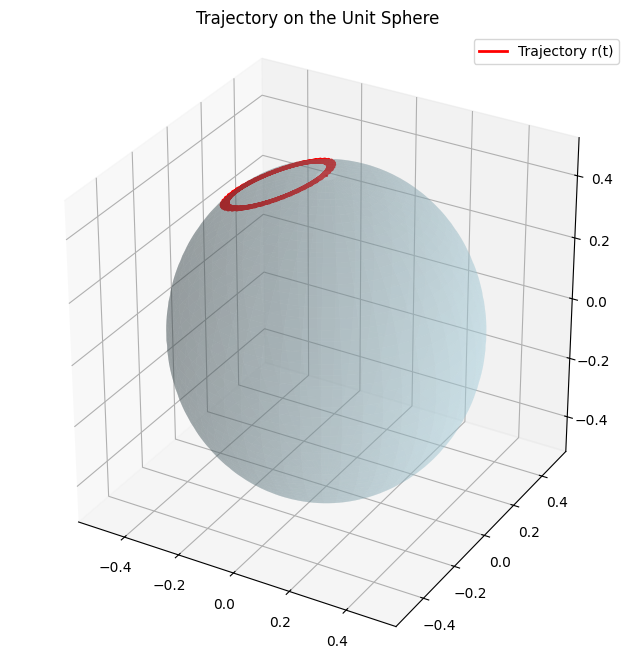

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define trajectory on the unit sphere
def trajectory(t, alpha=0.2):
    x = np.cos(t) * np.sin(alpha * t)
    y = np.sin(t) * np.sin(alpha * t)
    z = np.cos(alpha * t)
    return x, y, z

# Create parameter t
# t = np.linspace(0, 20*np.pi, 2000)
x, y, z = bloch(t,delta,omega)

# Create sphere surface
radius = 0.5
phi, theta = np.mgrid[0:np.pi:100j, 0:2*np.pi:100j]
x_sphere = np.sin(phi) * np.cos(theta)*radius
y_sphere = np.sin(phi) * np.sin(theta)*radius
z_sphere = np.cos(phi)*radius

# Plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot sphere surface
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.3, linewidth=0)

# Plot trajectory
ax.plot(x, y, z, color='red', linewidth=2, label="Trajectory r(t)")

# Formatting
ax.set_box_aspect([1,1,1])
ax.set_title("Trajectory on the Unit Sphere")
ax.legend()
plt.show()


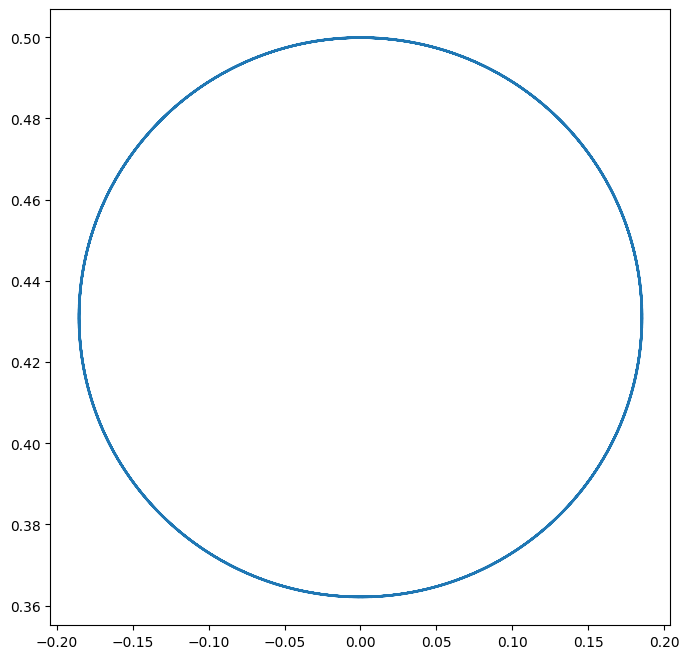

In [25]:
delta = 1
omega= 0.2
T = 2*np.pi/np.sqrt(delta**2/4+omega**2)*4
t = np.linspace(0,T,400)
x, y, z = bloch(t,delta,omega)

fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.plot(y,z)
plt.show()

/home/christian/Documents/master/python_env/lib/python3.12/site-packages/scipy/integrate/_ivp/ivp.py:621: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


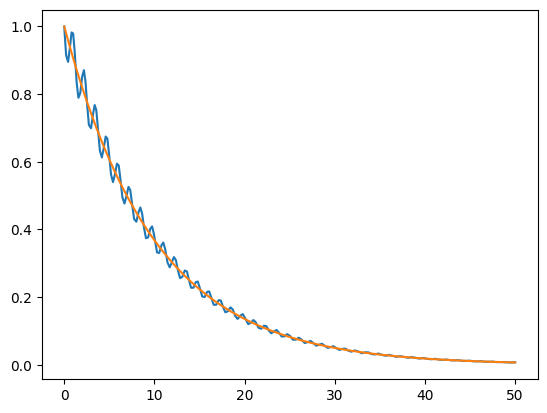

In [10]:
from scipy.integrate import solve_ivp
def kernel(t,x,A,B,w):
    dxdt = (-A-B*np.cos(w*t))*x
    return dxdt
a = 0.1
b = 4*a
w = 5
T= 5/a
sol = solve_ivp(kernel,[0,T],[1],args=(a,b,w),rtol=1e-15)
x = np.linspace(0,T,100)
plt.figure()
plt.plot(sol.t,sol.y[0])
plt.plot(x,np.exp(-a*x))
plt.show()